 # Distribuição Normal ou Gaussiana (A "Curva de Sino") #

- Uma distribuição normal é conhecida como uma curva em forma de sino.
- Curva de densidade simétrica.
- A distribuição normal é centrada em torno de sua média, com o desvio padrão indicando sua dispersão. 
- Os valores extremos são raros.
- A curva é contínua.
- **Exemplo:** Altura ou peso de uma população; erros de medição; notas de provas; tempo de atendimento em um banco.

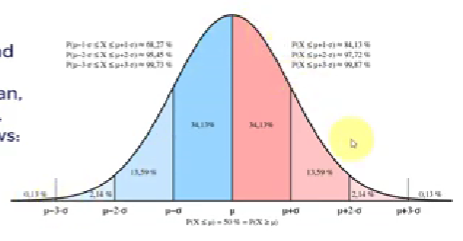


## Distribuição Normal Padrão ##

- Contém média = 0 e desvio padrão = 1.

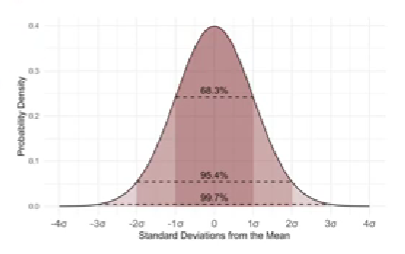


# Distribuição de Poisson #

- É uma distribuição de probabilidade discreta do número de eventos que ocorrem em um período de tempo específico.
- **Exemplo:** Número de e-mails recebidos em 1h; acidentes em uma estrada por dia; número de bactérias em uma amostra de água.

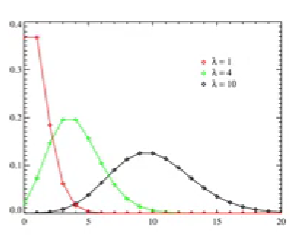


# Distribuição Binomial (O "Total de Sucessos") #

- Mede a probabilidade de sucesso ou fracasso quando o experimente é repetido várias vezes.
- A probabilidade p deve ser a mesma em todas as tentativas (independência).
- Existem apenas dois resultados possíveis em probabilidades fixas que somam um.
- **Exemplo:** Lançamento de uma moeda.

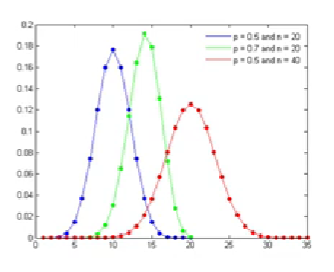


# Distribuição de Bernoulli - (O "Sim/Não") # 

- É um caso especial da distribuição binominal para n = 1.
- É uma distribuição binomial com uma única tentativa (ensaio) com duas alternativas de escolha.
- **Exemplo:** Lançamento de moeda; cliente comprou ou não comprou.

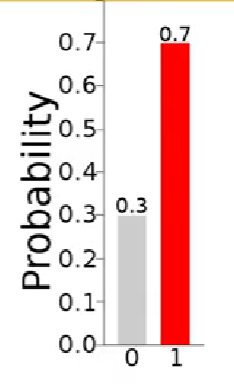

In [1]:
#Importando a biblioteca

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mostrando as primeiras linhas do data frame

df = pd.read_csv("economy.csv")
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"
...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,697"
206770,31-03-2022,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,"7,709"
206771,31-03-2022,Vistara,UK,826,12:30,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640"
206772,31-03-2022,Vistara,UK,822,09:45,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,"8,640"


In [3]:
df.dtypes

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price         object
dtype: object

In [4]:
# Converter a coluna 'price' de object para int 

df["price"] = df["price"].str.replace(",","") #remove vírgulas
df["price"] = pd.to_numeric(df["price"], errors="coerce") #converte para numérico

In [5]:
df.dtypes

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price          int64
dtype: object

In [6]:
# Converter a coluna 'dep_time' para date time

df["dep_time"] = pd.to_datetime(df["dep_time"], format="%H:%M")

In [7]:
# Criar a coluna com minutos desde meia-noite

df["dep_time_hour"] = (df["dep_time"].dt.hour * 60 + df["dep_time"].dt.minute)/60
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,dep_time_hour
0,11-02-2022,SpiceJet,SG,8709,1900-01-01 18:55:00,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,18.916667
1,11-02-2022,SpiceJet,SG,8157,1900-01-01 06:20:00,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,6.333333
2,11-02-2022,AirAsia,I5,764,1900-01-01 04:25:00,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,4.416667
3,11-02-2022,Vistara,UK,995,1900-01-01 10:20:00,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,10.333333
4,11-02-2022,Vistara,UK,963,1900-01-01 08:50:00,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,8.833333
...,...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7697,7.083333
206770,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7709,7.083333
206771,31-03-2022,Vistara,UK,826,1900-01-01 12:30:00,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,12.500000
206772,31-03-2022,Vistara,UK,822,1900-01-01 09:45:00,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,9.750000


In [8]:
# Converter a coluna 'time_taken' para objeto datetime

df[["hours","minutes"]] = df["time_taken"].str.extract(r'(\d+)h\s*(\d+)m') #extrair horas e minutos em uma única linha
df[["hours","minutes"]] = df[["hours","minutes"]].fillna(0).astype(int) #prrenche os valores ausentes antes de converter

In [9]:
# Converter para inteiro e calcular total em minutos

df = df.astype({"hours": int,"minutes":int})
df["time_taken_hour"] = round((df["hours"] * 60 + df["minutes"])/60,2)
df = df.drop(columns = ["hours","minutes"])
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,dep_time_hour,time_taken_hour
0,11-02-2022,SpiceJet,SG,8709,1900-01-01 18:55:00,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,18.916667,2.17
1,11-02-2022,SpiceJet,SG,8157,1900-01-01 06:20:00,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,6.333333,2.33
2,11-02-2022,AirAsia,I5,764,1900-01-01 04:25:00,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,4.416667,2.17
3,11-02-2022,Vistara,UK,995,1900-01-01 10:20:00,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,10.333333,2.25
4,11-02-2022,Vistara,UK,963,1900-01-01 08:50:00,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,8.833333,2.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7697,7.083333,13.83
206770,31-03-2022,Vistara,UK,832,1900-01-01 07:05:00,Chennai,13h 50m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:55,Hyderabad,7709,7.083333,13.83
206771,31-03-2022,Vistara,UK,826,1900-01-01 12:30:00,Chennai,20h 35m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,12.500000,20.58
206772,31-03-2022,Vistara,UK,822,1900-01-01 09:45:00,Chennai,23h 20m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,09:05,Hyderabad,8640,9.750000,23.33


In [10]:
# Estatísticas básicas de preço

media = round(df["price"].mean(),2)
mediana = np.median(df["price"])
minimo = np.min(df["price"])
maximo = np.max(df["price"])
desvio_padrao = round(np.std(df["price"]),2)

print("Em média o preço de um voo é",media)
print("Metade dos preços do voo estão abaixo do valor de",mediana)
print("O valor mínimo do preço do voo é",minimo)
print("O valor máximo do preço do voo é:",maximo)
print("Com variação de:", desvio_padrao) #mostra o quanto os valores estão espalhados em relação a média

Em média o preço de um voo é 6571.19
Metade dos preços do voo estão abaixo do valor de 5772.0
O valor mínimo do preço do voo é 1105
O valor máximo do preço do voo é: 42349
Com variação de: 3743.43


In [11]:
# Estatísticas básicas do horário de partida do vôo

media = round(df["dep_time_hour"].mean(),2)
mediana = round(np.median(df["dep_time_hour"]),2)
minimo = round(np.min(df["dep_time_hour"]),2)
maximo = round(np.max(df["dep_time_hour"]),2)
desvio_padrao = round(np.std(df["dep_time_hour"]),2)

print("Em média o horário de partida de um voo é",media, "h")
print("Metade dos horários de partida dos voos estão abaixo abaixo do valor de ",mediana,"h")
print("O mínimo de horário de partida de um voo é ",minimo, "h")
print("O máximo de horário de partida de um voo é :",maximo,"h")
print("Com variação de:", desvio_padrao, "h") #mostra o quanto os valores estão espalhados em relação a média

Em média o horário de partida de um voo é 13.29 h
Metade dos horários de partida dos voos estão abaixo abaixo do valor de  12.83 h
O mínimo de horário de partida de um voo é  0.17 h
O máximo de horário de partida de um voo é : 23.92 h
Com variação de: 5.38 h


In [12]:
# Estatísticas básicas do tempo de voo

media = round(df["time_taken_hour"].mean(),2)
mediana = round(np.median(df["time_taken_hour"]),2)
minimo = round(np.min(df["time_taken_hour"]),2)
maximo = round(np.max(df["time_taken_hour"]),2)
desvio_padrao = round(np.std(df["time_taken_hour"]),2)

print("Em média um voo tem duração de ",media, "h")
print("Metade das durações dos voos estão abaixo do valor de",mediana, "h")
print("O mínimo de duração de um voo é de:",minimo, "h")
print("O máximo de duração de um voo é de:",maximo, "h")
print("Com variação de:", desvio_padrao, "h") #mostra o quanto os valores estão espalhados em relação a média

Em média um voo tem duração de  11.55 h
Metade das durações dos voos estão abaixo do valor de 10.17 h
O mínimo de duração de um voo é de: 0.0 h
O máximo de duração de um voo é de: 49.83 h
Com variação de: 7.24 h


## Entregável obrigatório ##

Identificar 2 variáveis do dataset que “se parecem” com Normal, Binomial, etc. e escrever uma hipótese do tipo: “Esta variável poderia ser modelada como Poisson porque conta eventos…”.

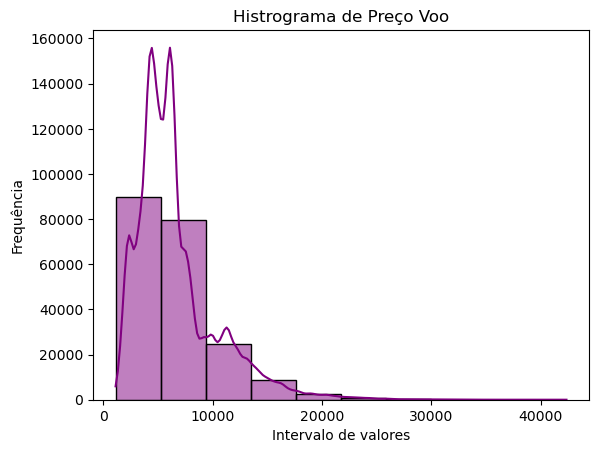

In [13]:
# Histograma da variável 'price'

sns.histplot(df["price"], bins=10, kde=True, color="purple")
plt.title("Histrograma de Preço Voo")
plt.xlabel("Intervalo de valores")
plt.ylabel("Frequência")
plt.show()

**Resolução:** Distribuição Binomial